#### Logostic regression w klasyfikacji binarner występowania raka piersi 

In [3]:
#importowanie modułów
import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.optim as optim
import matplotlib.pyplot as plt

In [11]:
#import danych
breast_cancer = datasets.load_breast_cancer() 
x, y = breast_cancer.data, breast_cancer.target

In [35]:
n_samples, n_features = x.shape
print(f'n_samples = {n_samples}, n_features = {n_features}')
print(x)

n_samples = 569, n_features = 30
[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]


In [37]:
#podział na zbiór testowy i treningowy
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
print(x_train.shape, x_test.shape)

(455, 30) (114, 30)


In [39]:
#skalowanie danych uczących
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
#transformacja danych testowych
x_test = sc.transform(x_test)

In [41]:
#konwersja numpy->torch
x_train = torch.from_numpy(x_train.astype(np.float32))
x_test = torch.from_numpy(x_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))
y_train.shape

torch.Size([455])

In [43]:
#przekształcenie do wektorów kolumnowych
y_train = y_train.view(y_train.shape[0],1)
y_test = y_test.view(y_test.shape[0],1)
y_train.shape

torch.Size([455, 1])

In [45]:
# prosty model
model_full = nn.Linear(x_train.shape[1], 1)
model_batch = nn.Linear(x_train.shape[1], 1)

In [47]:
criterion = nn.BCEWithLogitsLoss()

In [49]:
optimizer_full = optim.SGD(model_full.parameters(), lr=0.01)
optimizer_batch = optim.SGD(model_batch.parameters(), lr=0.01)

In [51]:
num_epochs = 50

losses_full = []
losses_batch = []

#### ===== FULL BATCH =====

In [54]:
for epoch in range(num_epochs):
    y_pred = model_full(x_train)
    loss = criterion(y_pred, y_train)

    optimizer_full.zero_grad()
    loss.backward()
    optimizer_full.step()

    losses_full.append(loss.item())

#### ===== MINI-BATCH =====

In [57]:
batch_size = 32

for epoch in range(num_epochs):
    permutation = torch.randperm(x_train.size(0))

    epoch_loss = 0

    for i in range(0, x_train.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = x_train[indices]
        batch_y = y_train[indices]

        y_pred = model_batch(batch_x)
        loss = criterion(y_pred, batch_y)

        optimizer_batch.zero_grad()
        loss.backward()
        optimizer_batch.step()

        epoch_loss += loss.item()

    losses_batch.append(epoch_loss)

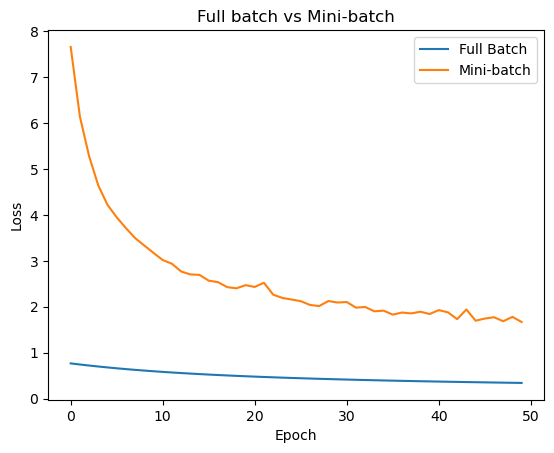

In [59]:
# ===== Wykres =====
plt.plot(losses_full, label="Full Batch")
plt.plot(losses_batch, label="Mini-batch")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Full batch vs Mini-batch")
plt.show()